In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 64

In [5]:
dataset = get_dataset("guacamayo",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

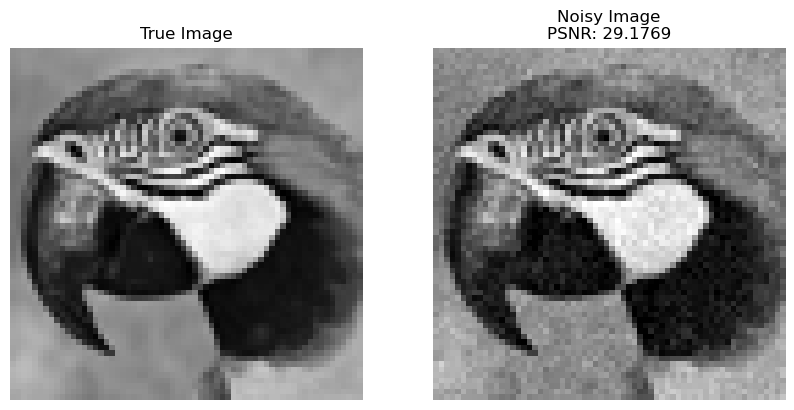

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.99)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.91343665]
[95.48195947]
[95.21668688]
[93.2492898]
[71.59560537]
[73.35119347]
[73.55644966]
[73.4733805]
[73.52716226]
[73.51061517]
[73.52478261]
[73.52388352]
[73.52335697]
[73.5203831]
[73.52215065]
[73.52203535]
[73.52198884]


In [9]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

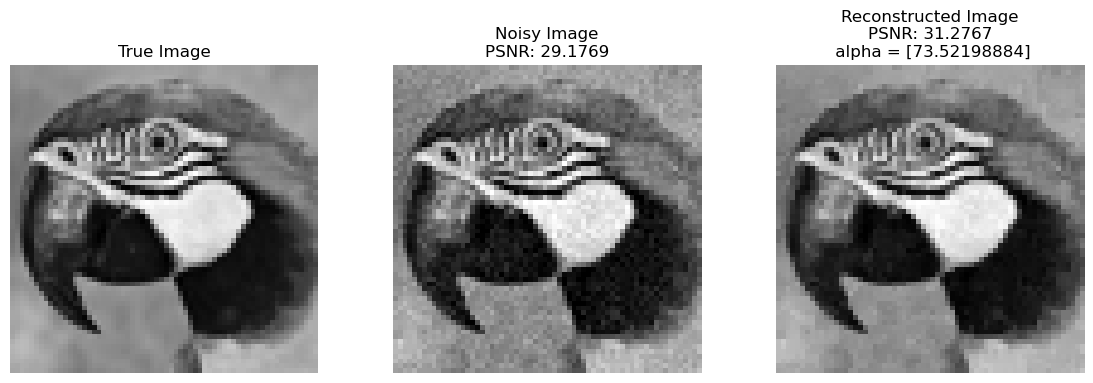

In [10]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)

In [11]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [12]:
mm = q.flatten().size # mm=2m...q\in R^2m
m = mm // 2 

Ku = K @ u.flatten() # u\in R^n
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

In [13]:
Kxu = Ku[:m]  # Primeras m componentes de Ku = [Kxu_{mxn}  Kyu_{mxn}]^T
Kyu = Ku[m:]  # Últimas m componentes
qx = q[:m]  # Primeras m componentes
qy = q[m:]  # Últimas m componentes
epsilon = 1e-10  

# Calculamos theta:
theta0 = np.zeros(m)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, multiplico por -1

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, multiplico por -1

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0 # asignamos 0

In [14]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [15]:
q_param = 0.99
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = q_param)

In [16]:
res_mpcc,x_opt_mpcc,fun_opt_mpcc, history = mpcc_model.solve(t_init=1e-3,max_iter=100,tol=1e-4,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

0                 0  1.508928511510812       0.5579342082446788               0.001

1                 0  1.516075655834941       0.36308991625633796             0.0005

2                 0  1.5201452680838816      0.23865223630204924            0.00025

3                 0  1.522438971626913       0.15457594032415206           0.000125

...

5                 0  1.5244070519359592      0.058431359693157256         3.125e-05

6                 0  1.524781087977933       0.03637674995756915         1.5625e-05

Intermediate fn: 1.524781087977933

complementarity: 0.03637674995756915

* (STOPPED) Iteration 8: Solving the NLP problem for t = 1e-05 with complementarity: 0.03637674995756915

In [17]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

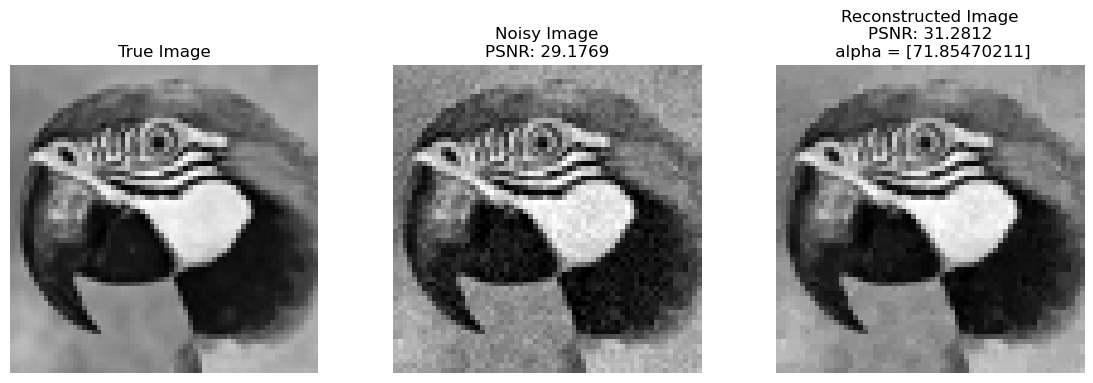

In [18]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)

In [19]:
def history_to_latex(
    history,
    experiment_name="tabla_mpcc",
):
    def fmt(x):
        if x is None:
            return "-"
        if isinstance(x, int):
            return f"{x}"
        x = float(x)
        # Formato decimal fijo, sin notación científica
        s = f"{x:.8f}"          # ajusta decimales si quieres
        s = s.rstrip('0').rstrip('.')  # limpia ceros finales
        return s

    lines = []
    lines.append("\\begin{tabular}{c c c c c c}")
    lines.append("\\toprule")
    lines.append("Iter & Compl & NLP iter & Fun Obj & $t$ & $\\alpha$ \\\\")
    lines.append("\\midrule")

    for row in history:
        lines.append(
            f"{fmt(row['k'])} & "
            f"{fmt(row['comp'])} & "
            f"{fmt(row['nlp_iter'])} & "
            f"{fmt(row['obj'])} & "
            f"{fmt(row['t'])} & "
            f"{fmt(row['alpha'])} \\\\"
        )

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    latex_table = "\n".join(lines)

    # -----------------------------
    # Crear carpeta y guardar
    # -----------------------------
    results_dir = "results_table"
    os.makedirs(results_dir, exist_ok=True)

    table_path = os.path.join(results_dir, f"{experiment_name}.tex")
    with open(table_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"Tabla LaTeX guardada en: {table_path}")

    return 

In [20]:
history_to_latex(
    history,
    experiment_name=(f"tabla_mpcc_{q_param}_{scale}"),
)

Tabla LaTeX guardada en: results_table\tabla_mpcc_0.99_64.tex
